# Convolutional Neural Network (CNN)

## Use MNIST Fashion dataset and create a classifier to classify fashion clothing into categories.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [26]:
#read data
train_df= pd.read_csv('fashion-mnist_train.csv')
# test_data=pd.read_csv('fashion-mnist_test.csv')

In [27]:
# Load original dataset
df = pd.read_csv("fashion-mnist_train.csv")

# Take 10,000 random rows as test data
test_df = df.sample(n=10000, random_state=42)

In [30]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,0,0,0,0,0,0,0,0,0,...,187,190,196,201,209,221,218,211,102,0
2,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (60000, 28, 28, 1)
Testing Data Shape  : (10000, 28, 28, 1)


In [34]:
# Extract feature values (all columns except 'label') from training dataset
X_train = train_df.drop(columns=["label"]).values  

# Extract target labels from training dataset
y_train = train_df["label"].values  

# Extract feature values (all columns except 'label') from testing dataset
X_test = test_df.drop(columns=["label"]).values  

# Extract target labels from testing dataset
y_test = test_df["label"].values  

In [35]:
# Preprocess
X_train = (X_train / 255.0).reshape(-1, 28, 28, 1)
X_test  = (X_test / 255.0).reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [36]:
# CNN model
model = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(),

    Conv2D(64, 3, activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/naveed-malik/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Train
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.7743 - loss: 0.6301 - val_accuracy: 0.8578 - val_loss: 0.3992
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.8514 - loss: 0.4198 - val_accuracy: 0.8773 - val_loss: 0.3439
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8712 - loss: 0.3613 - val_accuracy: 0.8862 - val_loss: 0.3074
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8832 - loss: 0.3259 - val_accuracy: 0.8992 - val_loss: 0.2784
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.8934 - loss: 0.3000 - val_accuracy: 0.9063 - val_loss: 0.2569
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.8991 - loss: 0.2799 - val_accuracy: 0.9102 - val_loss: 0.2519
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9046 - loss: 0.2613 - val_accuracy: 0.9105 - val_loss: 0.2506
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9096 - loss: 0.2469 - 

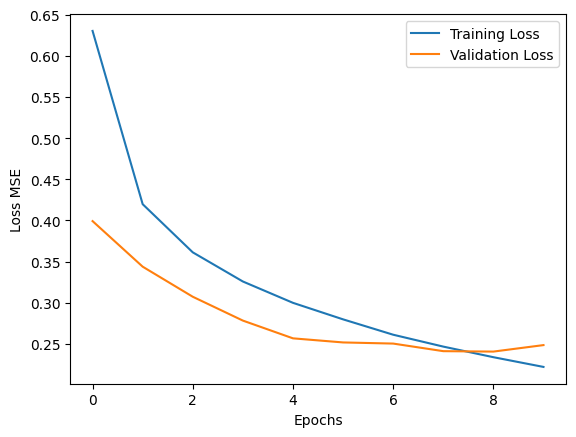

In [38]:
plt.plot(model.history.history["loss"], label="Training Loss")
plt.plot(model.history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss MSE")
plt.legend()
plt.show()

In [39]:
#Model evaluation
loss, accuracy = model.evaluate(x=X_test, y=y_test_cat)
print("Loss : ", loss)
print("Accuracy : ", accuracy*100) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9330 - loss: 0.1763
Loss :  0.17628462612628937
Accuracy :  93.30000281333923


In [40]:
# Evaluation
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1032
           1       1.00      0.98      0.99       974
           2       0.87      0.92      0.89      1001
           3       0.94      0.94      0.94      1037
           4       0.92      0.87      0.89       992
           5       0.98      1.00      0.99       946
           6       0.82      0.76      0.79      1047
           7       0.97      0.98      0.98       999
           8       1.00      0.98      0.99       952
           9       0.99      0.97      0.98      1020

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



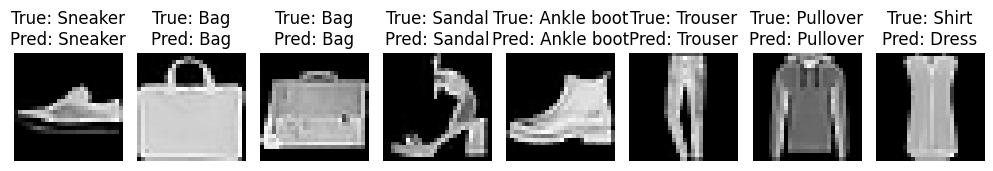

In [41]:
#Testing the prediction vs Actual or Sample predictions
labels = [
    'T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(10, 4))

for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title(f"True: {labels[y_test[i]]}\nPred: {labels[y_pred[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()